# ALS Collaborative Filtering — Personalized Product Recommendations

**Part 2b of the Recommendation System Module**

| Aspect | Detail |
|--------|--------|
| **PRD Requirement** | Suggestion de produits personnalisés (User-Specific Recommendations) |
| **Model** | ALS (Alternating Least Squares) |
| **Category** | Matrix Factorization (Collaborative Filtering) |
| **Comparison** | SVD (from notebook 02a), Popularity Baseline |
| **Evaluation** | Precision@K, Recall@K, F1@K, NDCG@K |

---

### How ALS Differs from SVD

Both SVD and ALS decompose the User × Item matrix into latent factors. The critical difference:

| | SVD | ALS |
|---|---|---|
| **Method** | Direct mathematical decomposition | Iterative optimization |
| **Training** | No training loop — one-shot factorization | Real training with loss function, convergence |
| **Loss function** | None (exact decomposition, then truncated) | Weighted MSE with regularization |
| **Handles implicit data** | Requires mean-centering hack | Natively designed for implicit feedback |
| **Regularization** | None | L2 regularization to prevent overfitting |
| **New data** | Full re-decomposition needed | Can incrementally update |

### ALS Algorithm

ALS minimizes the following loss function:

$$L = \sum_{u,i} c_{ui}(p_{ui} - x_u^T y_i)^2 + \lambda(\|x_u\|^2 + \|y_i\|^2)$$

Where:
- $p_{ui}$ = 1 if user u interacted with item i, else 0 (binary preference)
- $c_{ui}$ = 1 + α × r_{ui} (confidence — more purchases = higher confidence)
- $x_u$ = user latent factor vector
- $y_i$ = item latent factor vector  
- $\lambda$ = regularization strength

The "alternating" part: fix user factors → solve for item factors → fix item factors → solve for user factors → repeat until convergence.

> **This IS real model training** — with a loss function, iterative optimization, regularization, and convergence. Unlike SVD which is a one-shot decomposition.

---
## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import os
import time
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
from collections import defaultdict

warnings.filterwarnings('ignore')
np.random.seed(42)  # Same seed as SVD notebook for fair comparison

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

DATASETS_DIR = os.path.join('..', 'datasets')
ALS_DIR = os.path.join('..', 'ALS')
SVD_DIR = os.path.join('..', 'SVD')

print('Setup complete.')

Setup complete.


---
## 2. Load Data & Build Interaction Matrix

Same data loading and matrix construction as the SVD notebook — this ensures a fair comparison.

In [2]:
df = pd.read_csv(os.path.join(DATASETS_DIR, 'enterprise_pos_dataset.csv'), sep='|')
customers_df = pd.read_csv(os.path.join(DATASETS_DIR, 'customers.csv'))

print(f'Transactions:     {len(df):,} rows')
print(f'Unique customers: {df["customer_id"].nunique()}')
print(f'Unique items:     {df["item_name"].nunique()}')

# Build user-item interaction matrix (same as SVD notebook)
user_item = df.groupby(['customer_id', 'item_name']).size().reset_index(name='purchase_count')

user_item_matrix = user_item.pivot(
    index='customer_id',
    columns='item_name',
    values='purchase_count'
).fillna(0)

user_ids = user_item_matrix.index.tolist()
item_names = user_item_matrix.columns.tolist()
user_id_to_idx = {uid: i for i, uid in enumerate(user_ids)}
item_name_to_idx = {name: i for i, name in enumerate(item_names)}

n_users, n_items = user_item_matrix.shape
sparsity = 1 - ((user_item_matrix > 0).sum().sum() / (n_users * n_items))

print(f'\nMatrix: {n_users} users × {n_items} items | Sparsity: {sparsity:.1%}')

Transactions:     178,839 rows
Unique customers: 9991
Unique items:     122

Matrix: 9991 users × 122 items | Sparsity: 89.5%


---
## 3. Train/Test Split

**Critical:** We use the exact same random seed and split logic as the SVD notebook. Same train set, same test set, same held-out items. This is the only way to make a fair comparison.

In [3]:
train_matrix = user_item_matrix.copy()
test_items = defaultdict(set)

for uid in user_ids:
    user_purchases = user_item_matrix.loc[uid]
    purchased_items = user_purchases[user_purchases > 0].index.tolist()

    if len(purchased_items) >= 5:
        n_test = max(1, int(len(purchased_items) * 0.2))
        held_out = np.random.choice(purchased_items, size=n_test, replace=False)

        for item in held_out:
            test_items[uid].add(item)
            train_matrix.loc[uid, item] = 0

n_test_interactions = sum(len(v) for v in test_items.values())
print(f'Train interactions:  {(train_matrix > 0).sum().sum():,}')
print(f'Test interactions:   {n_test_interactions:,}')
print(f'Users with test data: {len(test_items)}')

Train interactions:  106,584
Test interactions:   21,479
Users with test data: 7678


---
## 4. Evaluation Functions

Same evaluation functions as SVD notebook — identical metrics for fair comparison.

In [4]:
def evaluate_recommendations(predicted_scores, train_matrix, test_items, user_ids, item_names, user_id_to_idx, top_k=5):
    """
    Evaluate a recommendation model using Precision@K, Recall@K, F1@K, and NDCG@K.
    """
    precision_scores = []
    recall_scores = []
    ndcg_scores = []

    for uid in test_items:
        if uid not in user_id_to_idx:
            continue

        uid_idx = user_id_to_idx[uid]
        user_preds = predicted_scores[uid_idx]

        already_purchased = set(train_matrix.columns[train_matrix.loc[uid] > 0])

        candidates = [(i, item, user_preds[i]) for i, item in enumerate(item_names) if item not in already_purchased]
        candidates.sort(key=lambda x: x[2], reverse=True)
        top_n = [item for _, item, _ in candidates[:top_k]]

        hits = len(set(top_n) & test_items[uid])
        precision_scores.append(hits / top_k)
        recall_scores.append(hits / len(test_items[uid]))

        dcg = 0.0
        for rank, item in enumerate(top_n):
            if item in test_items[uid]:
                dcg += 1.0 / np.log2(rank + 2)
        ideal_hits = min(len(test_items[uid]), top_k)
        idcg = sum(1.0 / np.log2(i + 2) for i in range(ideal_hits))
        ndcg_scores.append(dcg / idcg if idcg > 0 else 0.0)

    avg_precision = np.mean(precision_scores)
    avg_recall = np.mean(recall_scores)
    avg_f1 = 2 * avg_precision * avg_recall / (avg_precision + avg_recall) if (avg_precision + avg_recall) > 0 else 0
    avg_ndcg = np.mean(ndcg_scores)

    return {
        'precision@k': avg_precision,
        'recall@k': avg_recall,
        'f1@k': avg_f1,
        'ndcg@k': avg_ndcg
    }


def print_metrics(name, metrics):
    print(f'  {name:<25} | Precision@5: {metrics["precision@k"]:.4f} | Recall@5: {metrics["recall@k"]:.4f} | F1@5: {metrics["f1@k"]:.4f} | NDCG@5: {metrics["ndcg@k"]:.4f}')


print('Evaluation functions defined.')

Evaluation functions defined.


---
## 5. Popularity Baseline

Same baseline as SVD notebook — the bar both models must beat.

In [5]:
item_popularity = train_matrix.sum(axis=0).values
popularity_scores = np.tile(item_popularity, (n_users, 1))

popularity_metrics = evaluate_recommendations(
    popularity_scores, train_matrix, test_items, user_ids, item_names, user_id_to_idx, top_k=5
)

print('--- BASELINE: Popularity Recommender ---')
print_metrics('Popularity (Top-5)', popularity_metrics)

--- BASELINE: Popularity Recommender ---
  Popularity (Top-5)        | Precision@5: 0.0590 | Recall@5: 0.1018 | F1@5: 0.0747 | NDCG@5: 0.0994


---
## 6. ALS Implementation from Scratch

We implement ALS manually so we can:
1. Show the training loop with loss convergence 
2. Have full control over hyperparameters
3. Demonstrate understanding for the defense

The algorithm alternates between two closed-form solutions:
- **Fix items, solve for users:** $x_u = (Y^T C^u Y + \lambda I)^{-1} Y^T C^u p_u$
- **Fix users, solve for items:** $y_i = (X^T C^i X + \lambda I)^{-1} X^T C^i p_i$

Where $C^u$ is the diagonal confidence matrix for user u.

In [6]:
class ALSImplicit:
    """
    Alternating Least Squares for Implicit Feedback.
    
    Based on: "Collaborative Filtering for Implicit Feedback Datasets" (Hu, Koren, Volinsky, 2008)
    
    Parameters:
        n_factors: number of latent factors (k)
        regularization: L2 regularization strength (lambda)
        alpha: confidence scaling factor
        n_iterations: number of ALS iterations
    """
    
    def __init__(self, n_factors=10, regularization=0.1, alpha=40, n_iterations=15):
        self.n_factors = n_factors
        self.regularization = regularization
        self.alpha = alpha
        self.n_iterations = n_iterations
        self.user_factors = None
        self.item_factors = None
        self.loss_history = []
    
    def fit(self, interaction_matrix):
        """
        Train the ALS model.
        
        Parameters:
            interaction_matrix: np.array (n_users × n_items) — raw interaction counts
        """
        n_users, n_items = interaction_matrix.shape
        
        # Binary preference matrix: p_ui = 1 if r_ui > 0, else 0
        P = (interaction_matrix > 0).astype(float)
        
        # Confidence matrix: c_ui = 1 + alpha * r_ui
        C = 1 + self.alpha * interaction_matrix
        
        # Initialize factors randomly (small values)
        self.user_factors = np.random.normal(0, 0.01, (n_users, self.n_factors))
        self.item_factors = np.random.normal(0, 0.01, (n_items, self.n_factors))
        
        self.loss_history = []
        lambda_eye = self.regularization * np.eye(self.n_factors)
        
        print(f'  Training ALS: {n_users} users × {n_items} items, k={self.n_factors}, λ={self.regularization}, α={self.alpha}')
        print(f'  {"Iter":>6} | {"Loss":>12} | {"Δ Loss":>10} | {"Time":>8}')
        print(f'  {"-"*6}-+-{"-"*12}-+-{"-"*10}-+-{"-"*8}')
        
        for iteration in range(self.n_iterations):
            start_time = time.time()
            
            # --- Step 1: Fix item factors, solve for user factors ---
            YtY = self.item_factors.T @ self.item_factors  # k × k (precompute)
            for u in range(n_users):
                # C^u is diagonal with c_ui values for this user
                c_u = C[u]  # (n_items,)
                p_u = P[u]  # (n_items,)
                
                # Y^T C^u Y + λI
                # = Y^T Y + Y^T (C^u - I) Y + λI  (optimization: avoid full diagonal multiplication)
                c_u_minus_1 = c_u - 1  # Only non-zero where user has interactions
                nonzero_idx = np.where(c_u_minus_1 > 0)[0]
                
                A = YtY + lambda_eye
                if len(nonzero_idx) > 0:
                    Y_nonzero = self.item_factors[nonzero_idx]  # (nnz, k)
                    A += Y_nonzero.T @ np.diag(c_u_minus_1[nonzero_idx]) @ Y_nonzero
                
                # Y^T C^u p_u
                b = self.item_factors.T @ (c_u * p_u)
                
                self.user_factors[u] = np.linalg.solve(A, b)
            
            # --- Step 2: Fix user factors, solve for item factors ---
            XtX = self.user_factors.T @ self.user_factors  # k × k (precompute)
            for i in range(n_items):
                c_i = C[:, i]  # (n_users,)
                p_i = P[:, i]  # (n_users,)
                
                c_i_minus_1 = c_i - 1
                nonzero_idx = np.where(c_i_minus_1 > 0)[0]
                
                A = XtX + lambda_eye
                if len(nonzero_idx) > 0:
                    X_nonzero = self.user_factors[nonzero_idx]
                    A += X_nonzero.T @ np.diag(c_i_minus_1[nonzero_idx]) @ X_nonzero
                
                b = self.user_factors.T @ (c_i * p_i)
                
                self.item_factors[i] = np.linalg.solve(A, b)
            
            # --- Compute loss ---
            predicted = self.user_factors @ self.item_factors.T
            weighted_errors = C * (P - predicted) ** 2
            reg_term = self.regularization * (np.sum(self.user_factors ** 2) + np.sum(self.item_factors ** 2))
            loss = np.sum(weighted_errors) + reg_term
            
            delta = self.loss_history[-1] - loss if self.loss_history else 0
            self.loss_history.append(loss)
            elapsed = time.time() - start_time
            
            print(f'  {iteration+1:>6} | {loss:>12.2f} | {delta:>+10.2f} | {elapsed:>7.2f}s')
        
        print(f'\n  Training complete. Final loss: {self.loss_history[-1]:.2f}')
        return self
    
    def predict(self):
        """Return the full predicted score matrix."""
        return self.user_factors @ self.item_factors.T
    
    def predict_user(self, user_idx):
        """Return predicted scores for a single user."""
        return self.user_factors[user_idx] @ self.item_factors.T


print('ALS class defined.')

ALS class defined.


---
## 7. ALS — Hyperparameter Search

ALS has more hyperparameters than SVD:
- **n_factors (k)**: number of latent factors — same as SVD
- **regularization (λ)**: prevents overfitting by penalizing large factor values
- **alpha (α)**: scales the confidence — higher α means more weight on observed interactions
- **n_iterations**: how many alternating steps to run

We first sweep k (like SVD), then tune α and λ with the best k.

In [7]:
train_np = train_matrix.values.astype(float)

# --- Phase 1: Sweep k values (same as SVD) ---
print('=' * 70)
print('PHASE 1: Sweeping k (latent factors)')
print('=' * 70)

K_VALUES = [5, 10, 15, 20, 30]
als_k_results = {}

for k in K_VALUES:
    print(f'\n--- k={k} ---')
    model = ALSImplicit(n_factors=k, regularization=0.1, alpha=40, n_iterations=20)
    model.fit(train_np)
    
    predicted = model.predict()
    metrics = evaluate_recommendations(
        predicted, train_matrix, test_items, user_ids, item_names, user_id_to_idx, top_k=5
    )
    als_k_results[k] = {'metrics': metrics, 'loss_history': model.loss_history.copy()}
    print_metrics(f'ALS (k={k})', metrics)

best_k_als = max(als_k_results, key=lambda k: als_k_results[k]['metrics']['f1@k'])
print(f'\n>>> Best k = {best_k_als} (by F1@5: {als_k_results[best_k_als]["metrics"]["f1@k"]:.4f})')

PHASE 1: Sweeping k (latent factors)

--- k=5 ---
  Training ALS: 9991 users × 122 items, k=5, λ=0.1, α=40
    Iter |         Loss |     Δ Loss |     Time
  -------+--------------+------------+---------
       1 |   3397923.51 |      +0.00 |    0.62s
       2 |    975733.72 | +2422189.79 |    0.67s
       3 |    812555.69 | +163178.04 |    0.64s
       4 |    729673.57 |  +82882.12 |    0.60s
       5 |    681532.30 |  +48141.26 |    0.63s
       6 |    647972.95 |  +33559.35 |    0.64s
       7 |    621816.38 |  +26156.57 |    0.62s
       8 |    600529.84 |  +21286.54 |    0.89s
       9 |    582777.47 |  +17752.37 |    0.89s
      10 |    567698.41 |  +15079.05 |    0.90s
      11 |    554700.59 |  +12997.82 |    0.84s
      12 |    543361.01 |  +11339.58 |    0.66s
      13 |    533368.21 |   +9992.80 |    0.69s
      14 |    524486.92 |   +8881.29 |    0.62s
      15 |    516535.46 |   +7951.46 |    0.63s
      16 |    509370.84 |   +7164.61 |    0.67s
      17 |    502878.69 |   

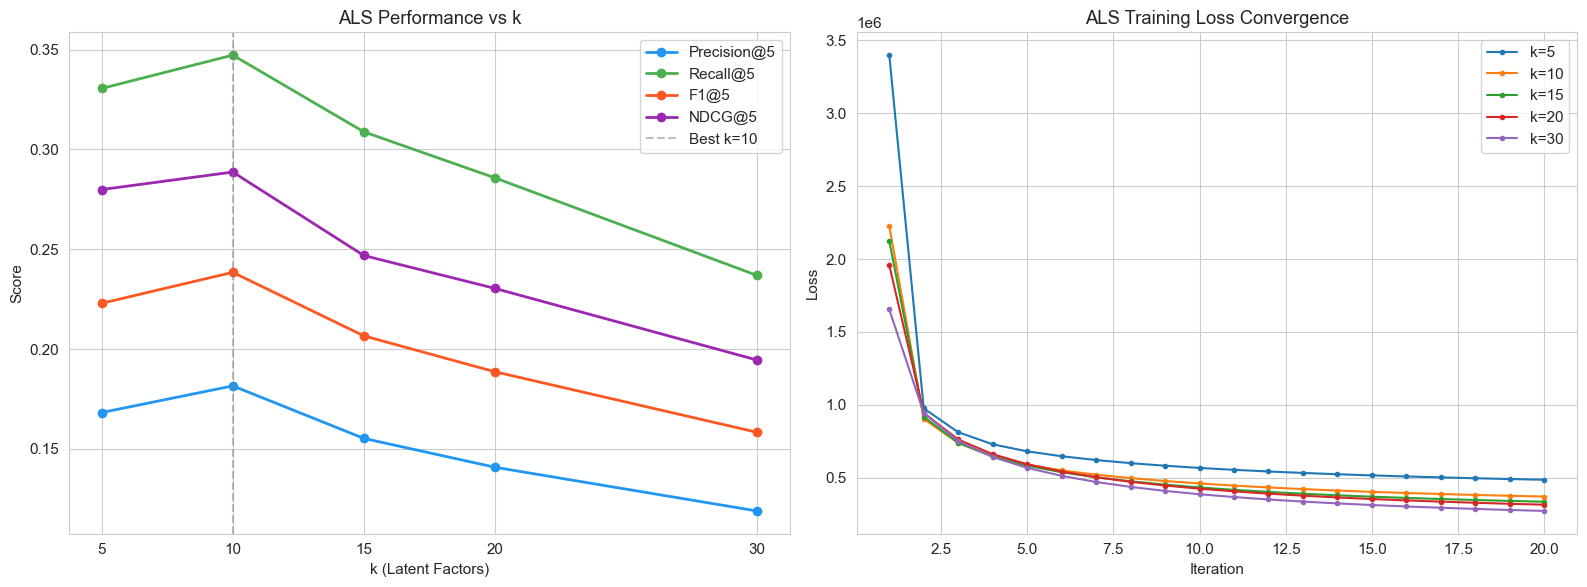

In [8]:
# Visualize k sweep
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Metrics vs k
ks = sorted(als_k_results.keys())
metrics_names = ['precision@k', 'recall@k', 'f1@k', 'ndcg@k']
colors = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0']
labels = ['Precision@5', 'Recall@5', 'F1@5', 'NDCG@5']

for metric, color, label in zip(metrics_names, colors, labels):
    values = [als_k_results[k]['metrics'][metric] for k in ks]
    axes[0].plot(ks, values, marker='o', linewidth=2, color=color, label=label)

axes[0].axvline(best_k_als, color='gray', linestyle='--', alpha=0.5, label=f'Best k={best_k_als}')
axes[0].set_xlabel('k (Latent Factors)')
axes[0].set_ylabel('Score')
axes[0].set_title('ALS Performance vs k')
axes[0].legend()
axes[0].set_xticks(ks)

# Plot 2: Loss convergence for each k
for k in ks:
    axes[1].plot(range(1, len(als_k_results[k]['loss_history']) + 1),
                 als_k_results[k]['loss_history'],
                 marker='.', linewidth=1.5, label=f'k={k}')

axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Loss')
axes[1].set_title('ALS Training Loss Convergence')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 8. ALS — Fine-tune α and λ with Best k

Now that we know the best k, we tune the other two critical hyperparameters:
- **α (alpha)**: confidence scaling — how much more we trust items with higher purchase counts
- **λ (regularization)**: overfitting control

In [9]:
print('=' * 70)
print(f'PHASE 2: Tuning α and λ with k={best_k_als}')
print('=' * 70)

ALPHA_VALUES = [10, 20, 40, 80]
LAMBDA_VALUES = [0.01, 0.1, 0.5, 1.0]

tuning_results = {}

for alpha in ALPHA_VALUES:
    for lam in LAMBDA_VALUES:
        print(f'\n--- α={alpha}, λ={lam} ---')
        model = ALSImplicit(n_factors=best_k_als, regularization=lam, alpha=alpha, n_iterations=15)
        model.fit(train_np)
        
        predicted = model.predict()
        metrics = evaluate_recommendations(
            predicted, train_matrix, test_items, user_ids, item_names, user_id_to_idx, top_k=5
        )
        tuning_results[(alpha, lam)] = metrics
        print_metrics(f'α={alpha}, λ={lam}', metrics)

# Find best combination
best_combo = max(tuning_results, key=lambda x: tuning_results[x]['f1@k'])
best_alpha, best_lambda = best_combo
print(f'\n>>> Best: α={best_alpha}, λ={best_lambda} (F1@5: {tuning_results[best_combo]["f1@k"]:.4f})')

PHASE 2: Tuning α and λ with k=10

--- α=10, λ=0.01 ---
  Training ALS: 9991 users × 122 items, k=10, λ=0.01, α=10
    Iter |         Loss |     Δ Loss |     Time
  -------+--------------+------------+---------
       1 |    636199.50 |      +0.00 |    1.69s
       2 |    330220.55 | +305978.95 |    1.49s
       3 |    291393.23 |  +38827.32 |    1.52s
       4 |    276570.11 |  +14823.12 |    1.99s
       5 |    267968.31 |   +8601.80 |    1.48s
       6 |    261641.53 |   +6326.78 |    1.49s
       7 |    256574.68 |   +5066.85 |    1.49s
       8 |    252351.88 |   +4222.80 |    1.49s
       9 |    248751.54 |   +3600.34 |    1.48s
      10 |    245634.75 |   +3116.80 |    1.51s
      11 |    242906.21 |   +2728.53 |    1.50s
      12 |    240497.01 |   +2409.20 |    1.51s
      13 |    238354.31 |   +2142.70 |    1.50s
      14 |    236435.79 |   +1918.52 |    1.49s
      15 |    234706.98 |   +1728.81 |    1.53s

  Training complete. Final loss: 234706.98
  α=10, λ=0.01           

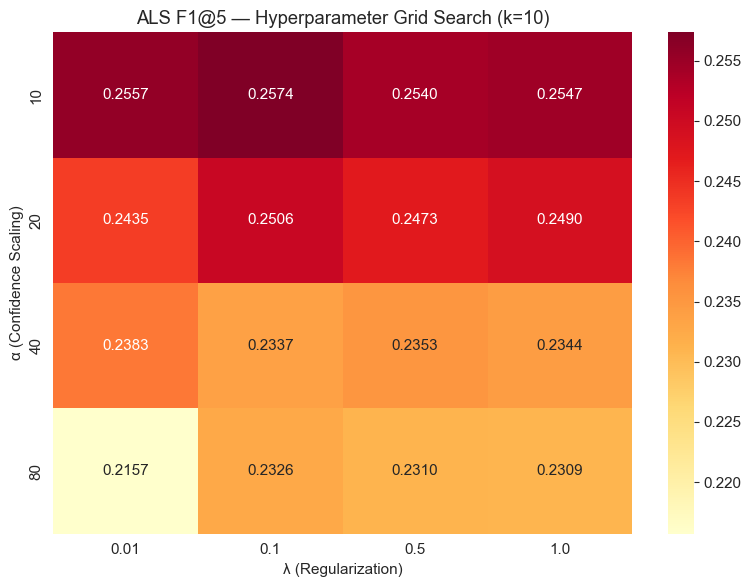

In [10]:
# Heatmap of F1 scores across α × λ grid
f1_grid = np.zeros((len(ALPHA_VALUES), len(LAMBDA_VALUES)))
for i, alpha in enumerate(ALPHA_VALUES):
    for j, lam in enumerate(LAMBDA_VALUES):
        f1_grid[i, j] = tuning_results[(alpha, lam)]['f1@k']

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    f1_grid, annot=True, fmt='.4f', cmap='YlOrRd',
    xticklabels=[str(l) for l in LAMBDA_VALUES],
    yticklabels=[str(a) for a in ALPHA_VALUES],
    ax=ax
)
ax.set_xlabel('λ (Regularization)')
ax.set_ylabel('α (Confidence Scaling)')
ax.set_title(f'ALS F1@5 — Hyperparameter Grid Search (k={best_k_als})')
plt.tight_layout()
plt.show()

---
## 9. Final ALS Model — Train with Best Hyperparameters

In [11]:
print(f'Training final ALS model: k={best_k_als}, α={best_alpha}, λ={best_lambda}')
print()

final_als = ALSImplicit(
    n_factors=best_k_als,
    regularization=best_lambda,
    alpha=best_alpha,
    n_iterations=20  # A few more iterations for the final model
)
final_als.fit(train_np)

als_predicted = final_als.predict()
final_als_metrics = evaluate_recommendations(
    als_predicted, train_matrix, test_items, user_ids, item_names, user_id_to_idx, top_k=5
)

print()
print_metrics(f'Final ALS', final_als_metrics)

Training final ALS model: k=10, α=10, λ=0.1

  Training ALS: 9991 users × 122 items, k=10, λ=0.1, α=10
    Iter |         Loss |     Δ Loss |     Time
  -------+--------------+------------+---------
       1 |    709959.34 |      +0.00 |    1.77s
       2 |    352668.82 | +357290.52 |    1.61s
       3 |    311198.94 |  +41469.88 |    1.67s
       4 |    292124.53 |  +19074.41 |    1.60s
       5 |    280305.48 |  +11819.05 |    2.20s
       6 |    271683.29 |   +8622.19 |    1.59s
       7 |    264889.69 |   +6793.60 |    1.66s
       8 |    259314.35 |   +5575.33 |    1.56s
       9 |    254633.65 |   +4680.71 |    1.59s
      10 |    250645.23 |   +3988.42 |    1.61s
      11 |    247206.91 |   +3438.32 |    1.63s
      12 |    244213.13 |   +2993.78 |    1.60s
      13 |    241583.49 |   +2629.64 |    1.60s
      14 |    239255.64 |   +2327.85 |    1.64s
      15 |    237180.56 |   +2075.08 |    1.60s
      16 |    235319.37 |   +1861.19 |    1.60s
      17 |    233640.99 |   +1678

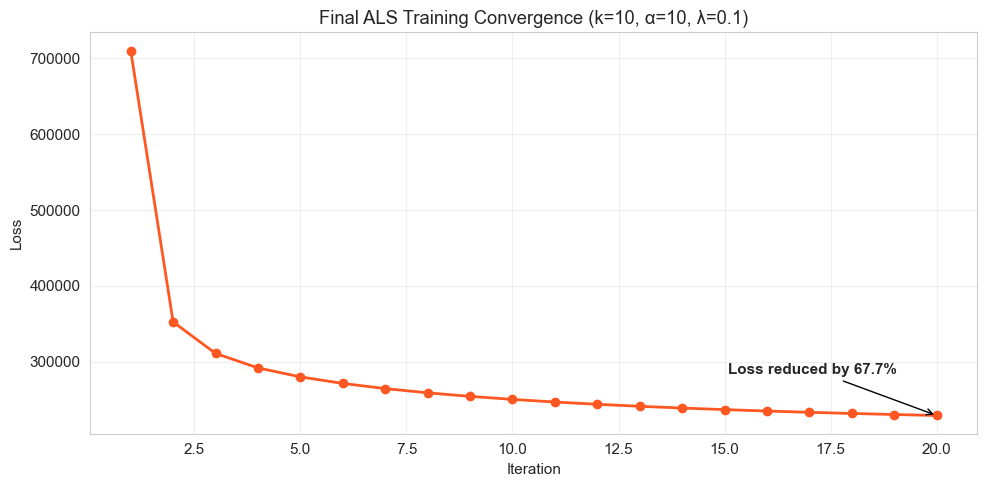

In [12]:
# Plot training convergence of final model
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(final_als.loss_history) + 1), final_als.loss_history,
        marker='o', linewidth=2, color='#FF5722')
ax.set_xlabel('Iteration')
ax.set_ylabel('Loss')
ax.set_title(f'Final ALS Training Convergence (k={best_k_als}, α={best_alpha}, λ={best_lambda})')
ax.grid(True, alpha=0.3)

# Annotate convergence
final_loss = final_als.loss_history[-1]
first_loss = final_als.loss_history[0]
reduction = (first_loss - final_loss) / first_loss * 100
ax.annotate(f'Loss reduced by {reduction:.1f}%',
            xy=(len(final_als.loss_history), final_loss),
            xytext=(-150, 30), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 10. Load SVD Results for Comparison

We load the SVD evaluation results saved from notebook 02a to do a head-to-head comparison.

In [13]:
# Load SVD results from notebook 02a
svd_eval_path = os.path.join(SVD_DIR, 'svd_evaluation_results.csv')

if os.path.exists(svd_eval_path):
    svd_eval_df = pd.read_csv(svd_eval_path)
    # Get the best SVD result (highest F1)
    best_svd_row = svd_eval_df[svd_eval_df['model'] != 'Popularity Baseline'].sort_values('f1@k', ascending=False).iloc[0]
    best_svd_metrics = {
        'precision@k': best_svd_row['precision@k'],
        'recall@k': best_svd_row['recall@k'],
        'f1@k': best_svd_row['f1@k'],
        'ndcg@k': best_svd_row['ndcg@k']
    }
    svd_model_name = best_svd_row['model']
    print(f'Loaded SVD results: {svd_model_name}')
    print_metrics(svd_model_name, best_svd_metrics)
else:
    print('⚠️  SVD evaluation results not found. Run notebook 02a first.')
    print(f'   Expected path: {svd_eval_path}')
    best_svd_metrics = None
    svd_model_name = None

Loaded SVD results: SVD (k=10)
  SVD (k=10)                | Precision@5: 0.2040 | Recall@5: 0.3736 | F1@5: 0.2639 | NDCG@5: 0.3285


---
## 11. Final Comparison — ALS vs SVD vs Popularity

In [14]:
print('=' * 80)
print('FINAL MODEL COMPARISON')
print('=' * 80)

print_metrics('Popularity Baseline', popularity_metrics)
if best_svd_metrics:
    print_metrics(svd_model_name, best_svd_metrics)
print_metrics(f'ALS (k={best_k_als}, α={best_alpha}, λ={best_lambda})', final_als_metrics)
print('=' * 80)

# Determine winner
if best_svd_metrics:
    svd_f1 = best_svd_metrics['f1@k']
    als_f1 = final_als_metrics['f1@k']
    pop_f1 = popularity_metrics['f1@k']
    
    print(f'\nALS vs Popularity:')
    if pop_f1 > 0:
        print(f'  F1@5 improvement: {((als_f1 - pop_f1) / pop_f1 * 100):+.1f}%')
    
    print(f'\nALS vs SVD:')
    if svd_f1 > 0:
        diff = ((als_f1 - svd_f1) / svd_f1 * 100)
        print(f'  F1@5 difference: {diff:+.1f}%')
        if diff > 0:
            print(f'  ✅ ALS outperforms SVD')
        elif diff < -1:
            print(f'  ✅ SVD outperforms ALS')
        else:
            print(f'  ≈ Models perform similarly')

FINAL MODEL COMPARISON
  Popularity Baseline       | Precision@5: 0.0590 | Recall@5: 0.1018 | F1@5: 0.0747 | NDCG@5: 0.0994
  SVD (k=10)                | Precision@5: 0.2040 | Recall@5: 0.3736 | F1@5: 0.2639 | NDCG@5: 0.3285
  ALS (k=10, α=10, λ=0.1)   | Precision@5: 0.1968 | Recall@5: 0.3677 | F1@5: 0.2564 | NDCG@5: 0.3142

ALS vs Popularity:
  F1@5 improvement: +243.1%

ALS vs SVD:
  F1@5 difference: -2.9%
  ✅ SVD outperforms ALS


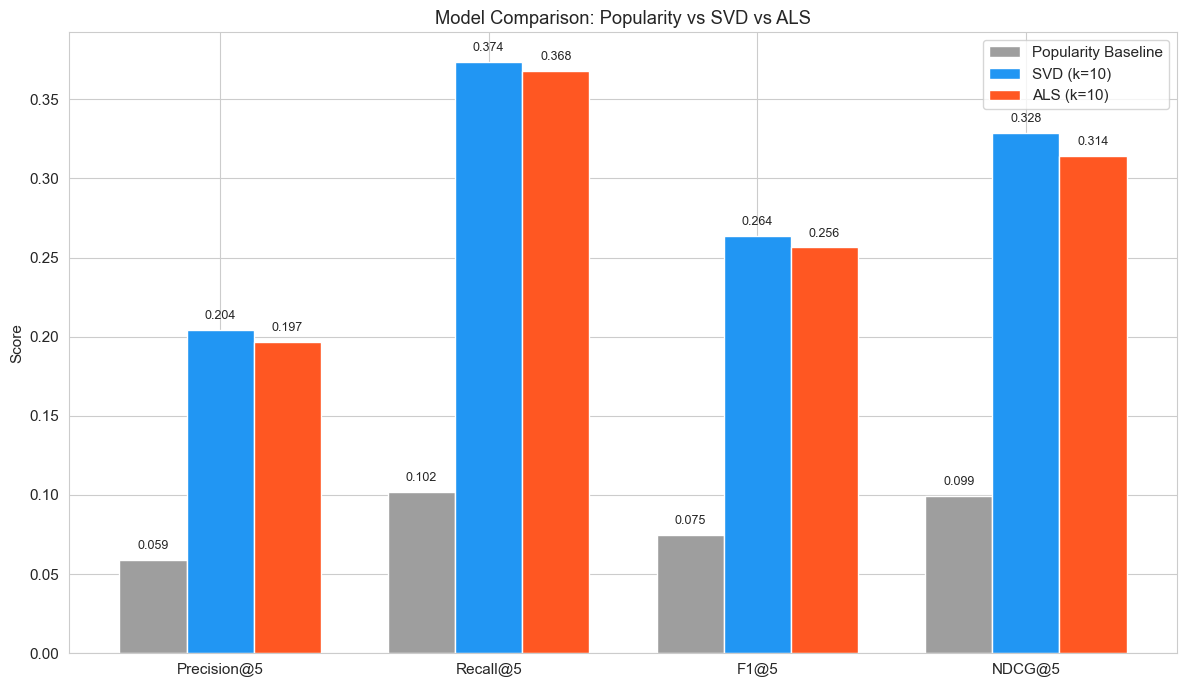

In [15]:
# Visual comparison — all three models
fig, ax = plt.subplots(figsize=(12, 7))

metrics_labels = ['Precision@5', 'Recall@5', 'F1@5', 'NDCG@5']
pop_vals = [popularity_metrics[m] for m in metrics_names]
als_vals = [final_als_metrics[m] for m in metrics_names]

x = np.arange(len(metrics_labels))

if best_svd_metrics:
    svd_vals = [best_svd_metrics[m] for m in metrics_names]
    width = 0.25
    bars1 = ax.bar(x - width, pop_vals, width, label='Popularity Baseline', color='#9E9E9E', edgecolor='white')
    bars2 = ax.bar(x, svd_vals, width, label=svd_model_name, color='#2196F3', edgecolor='white')
    bars3 = ax.bar(x + width, als_vals, width, label=f'ALS (k={best_k_als})', color='#FF5722', edgecolor='white')
    all_bars = [bars1, bars2, bars3]
else:
    width = 0.35
    bars1 = ax.bar(x - width/2, pop_vals, width, label='Popularity Baseline', color='#9E9E9E', edgecolor='white')
    bars3 = ax.bar(x + width/2, als_vals, width, label=f'ALS (k={best_k_als})', color='#FF5722', edgecolor='white')
    all_bars = [bars1, bars3]

# Add value labels
for bars in all_bars:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Score')
ax.set_title('Model Comparison: Popularity vs SVD vs ALS')
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels)
ax.legend()
plt.tight_layout()
plt.show()

---
## 12. Demo — ALS Recommendations for Sample Customers

In [16]:
def get_als_recommendations(customer_id, n=5):
    """Get top-N personalized ALS recommendations for a customer."""
    if customer_id not in user_id_to_idx:
        return None

    uid_idx = user_id_to_idx[customer_id]
    user_preds = als_predicted[uid_idx]

    already_purchased = set(user_item_matrix.columns[user_item_matrix.loc[customer_id] > 0])

    item_scores = [(item, user_preds[i]) for i, item in enumerate(item_names) if item not in already_purchased]
    item_scores.sort(key=lambda x: x[1], reverse=True)
    return item_scores[:n]


# Same demo customers as SVD notebook
demo_customers = []
for archetype in ['regular', 'occasional', 'infrequent']:
    arch_customers = customers_df[customers_df['archetype'] == archetype]
    for _, c in arch_customers.iterrows():
        cid = c['customer_id']
        if cid in user_id_to_idx:
            n_purchased = (user_item_matrix.loc[cid] > 0).sum()
            if n_purchased >= 5:
                demo_customers.append(cid)
                break

print('=' * 70)
print('ALS RECOMMENDATION DEMOS')
print('=' * 70)

for cid in demo_customers:
    cust_info = customers_df[customers_df['customer_id'] == cid].iloc[0]
    purchased = user_item_matrix.loc[cid]
    purchased_items = purchased[purchased > 0].sort_values(ascending=False)

    print(f'  Customer {cid} ({cust_info["archetype"]}) | Sections: {cust_info["preferred_sections"]}')
    print(f'  Purchase history ({len(purchased_items)} unique items):')
    for item, count in purchased_items.head(6).items():
        print(f'    {item}: {int(count)}x')

    recs = get_als_recommendations(cid, n=5)
    print(f'  → ALS Recommendations:')
    for item, score in recs:
        print(f'    {item} (score: {score:.4f})')
    print()

ALS RECOMMENDATION DEMOS
  Customer 447 (regular) | Sections: Cafe
  Purchase history (26 unique items):
    Oatmeal with Berries: 6x
    Avocado Toast: 5x
    Breakfast Sandwich (Egg & Cheese): 3x
    Chocolate Chip Cookie: 3x
    Almond Croissant: 3x
    Caramel Macchiato: 2x
  → ALS Recommendations:
    Cold Brew Coffee (score: 0.9370)
    Cappuccino (score: 0.8899)
    Tuna Sashimi (5pc) (score: 0.8853)
    Bacon Double Burger (score: 0.8437)
    Chicken Tenders (4pc) (score: 0.8342)

  Customer 1774 (occasional) | Sections: Healthy_Vegan,American
  Purchase history (12 unique items):
    Coca-Cola: 4x
    Bacon Double Burger: 3x
    Chicken Tenders (4pc): 3x
    Classic Cheeseburger: 2x
    Crispy Chicken Sandwich: 1x
    Dr Pepper: 1x
  → ALS Recommendations:
    Diet Coke (score: 1.0004)
    Spicy BBQ Bacon Burger (score: 0.9715)
    Philly Cheesesteak (score: 0.9678)
    Buffalo Wings (10pc) (score: 0.9238)
    Loaded Nachos (score: 0.8356)

  Customer 5485 (infrequent) | Secti

---
## 13. Save Outputs

In [17]:
# Save ALS predicted scores
als_pred_df = pd.DataFrame(als_predicted, index=user_ids, columns=item_names)
als_pred_df.to_csv(os.path.join(ALS_DIR, 'als_predicted_ratings.csv'))
print(f'Saved: als_predicted_ratings.csv ({als_pred_df.shape})')

# Save ALS evaluation results
als_eval_rows = [{'model': 'Popularity Baseline', **popularity_metrics}]
for k, data in sorted(als_k_results.items()):
    als_eval_rows.append({'model': f'ALS (k={k})', **data['metrics']})
als_eval_rows.append({'model': f'ALS Final (k={best_k_als}, α={best_alpha}, λ={best_lambda})', **final_als_metrics})

als_eval_df = pd.DataFrame(als_eval_rows)
als_eval_df.to_csv(os.path.join(ALS_DIR, 'als_evaluation_results.csv'), index=False)
print(f'Saved: als_evaluation_results.csv')

# Save ALS model factors
np.savez(
    os.path.join(ALS_DIR, 'als_model_factors.npz'),
    user_factors=final_als.user_factors,
    item_factors=final_als.item_factors
)
print(f'Saved: als_model_factors.npz')

# Save combined comparison (for use in final summary notebook)
combined_rows = [
    {'model': 'Popularity Baseline', **popularity_metrics}
]
if best_svd_metrics:
    combined_rows.append({'model': svd_model_name, **best_svd_metrics})
combined_rows.append({'model': f'ALS (k={best_k_als}, α={best_alpha}, λ={best_lambda})', **final_als_metrics})

combined_df = pd.DataFrame(combined_rows)
combined_df.to_csv(os.path.join(ALS_DIR, 'svd_vs_als_comparison.csv'), index=False)
print(f'Saved: svd_vs_als_comparison.csv')

Saved: als_predicted_ratings.csv ((9991, 122))
Saved: als_evaluation_results.csv
Saved: als_model_factors.npz
Saved: svd_vs_als_comparison.csv


---
## 14. Summary & Conclusions

In [18]:
print('=' * 70)
print('ALS COLLABORATIVE FILTERING — SUMMARY')
print('=' * 70)

print(f'\nDataset: {n_users} users × {n_items} items | Sparsity: {sparsity:.1%}')
print(f'\nBest ALS config: k={best_k_als}, α={best_alpha}, λ={best_lambda}')
print(f'Training: {len(final_als.loss_history)} iterations')
print(f'Loss reduction: {final_als.loss_history[0]:.0f} → {final_als.loss_history[-1]:.0f} ({(1 - final_als.loss_history[-1]/final_als.loss_history[0])*100:.1f}% reduction)')

print(f'\n--- Final Comparison ---')
print_metrics('Popularity Baseline', popularity_metrics)
if best_svd_metrics:
    print_metrics(svd_model_name, best_svd_metrics)
print_metrics(f'ALS Final', final_als_metrics)

print(f'\nKey characteristics of ALS vs SVD:')
print(f'  - ALS IS iterative training (real loss function, convergence, regularization)')
print(f'  - ALS natively handles implicit feedback (purchase counts → confidence)')
print(f'  - ALS has more hyperparameters to tune (k, α, λ) but more flexibility')
print(f'  - SVD is faster (one-shot) but has no regularization and no confidence weighting')
print(f'\n→ Next: Factorization Machines (notebook 02c) for context-aware recommendations.')

ALS COLLABORATIVE FILTERING — SUMMARY

Dataset: 9991 users × 122 items | Sparsity: 89.5%

Best ALS config: k=10, α=10, λ=0.1
Training: 20 iterations
Loss reduction: 709959 → 229473 (67.7% reduction)

--- Final Comparison ---
  Popularity Baseline       | Precision@5: 0.0590 | Recall@5: 0.1018 | F1@5: 0.0747 | NDCG@5: 0.0994
  SVD (k=10)                | Precision@5: 0.2040 | Recall@5: 0.3736 | F1@5: 0.2639 | NDCG@5: 0.3285
  ALS Final                 | Precision@5: 0.1968 | Recall@5: 0.3677 | F1@5: 0.2564 | NDCG@5: 0.3142

Key characteristics of ALS vs SVD:
  - ALS IS iterative training (real loss function, convergence, regularization)
  - ALS natively handles implicit feedback (purchase counts → confidence)
  - ALS has more hyperparameters to tune (k, α, λ) but more flexibility
  - SVD is faster (one-shot) but has no regularization and no confidence weighting

→ Next: Factorization Machines (notebook 02c) for context-aware recommendations.
